# Chapter 11 — General Linear Models and Least Squares

## Learning Objectives

This notebook covers design matrices, regression coefficients, least-squares fitting, residuals, and QR-based least squares.

## Theoretical Explanation

A general linear model expresses data as a weighted combination of predictors: `Xβ ≈ y`. The design matrix `X` contains predictors, the coefficient vector `β` contains weights, and `y` contains observed outcomes. Least squares chooses coefficients that minimize the squared residual error.

Geometrically, least squares projects `y` onto the column space of `X`. If `y` is not exactly in that column space, the model finds the closest approximation.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import norm, matrix_rank

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Least Squares by Normal Equation

beta intercept and slope: [5.129 2.384]
MSE: 3.301


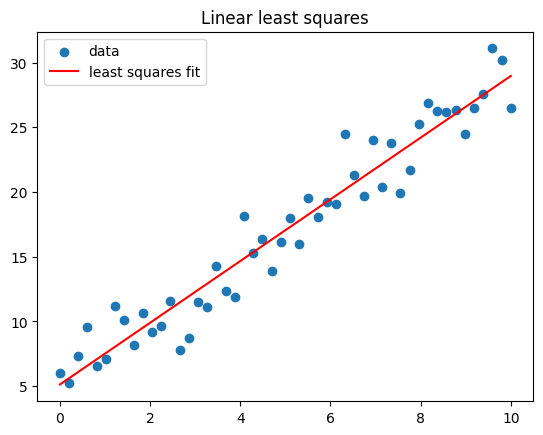

In [2]:
rng = np.random.RandomState(RANDOM_STATE)
x = np.linspace(0,10,50)
y = 2.5*x + 5 + rng.normal(0,2,size=len(x))
X = np.column_stack([np.ones_like(x), x])
beta = np.linalg.inv(X.T @ X) @ X.T @ y
pred = X @ beta
print('beta intercept and slope:', np.round(beta,3))
print('MSE:', round(np.mean((y-pred)**2),3))
plt.scatter(x,y,label='data')
plt.plot(x,pred,color='red',label='least squares fit')
plt.legend(); plt.title('Linear least squares')
plt.show()

### Output Interpretation

The estimated coefficients define the line that minimizes squared residuals. The intercept and slope are the weights in the linear model.

## 2. Least Squares via QR

In [3]:
Q, R = np.linalg.qr(X)
beta_qr = np.linalg.solve(R, Q.T @ y)
print('Normal equation beta:', np.round(beta,6))
print('QR beta:', np.round(beta_qr,6))
print('Difference:', norm(beta-beta_qr))

Normal equation beta: [5.128886 2.384033]
QR beta: [5.128886 2.384033]
Difference: 1.6011864169946884e-15


### Output Interpretation

The QR-based solution matches the normal equation solution but is generally more numerically stable because it avoids explicitly inverting `X.T @ X`.

## Extended Study Notes

The central learning objective is not only to run code, but to connect the numerical result back to the linear algebra idea. In applied data science, vectors and matrices are not abstract objects only; they are the representation layer for observations, features, images, time series, model parameters, transformations, and decompositions.

A professional workflow should always include sanity checks. For example, reconstructed matrices should be compared with the original matrix, orthogonal matrices should be checked with `Q.T @ Q`, inverse computations should be checked against the identity matrix, and least-squares predictions should be inspected through residuals. These checks make the notebook academically stronger and reduce the risk of blindly trusting a black-box function.

## Chapter Summary

This notebook reproduces the core concept of the chapter using original/adapted Python examples. The code is intentionally compact but runnable, and the surrounding explanation focuses on conceptual understanding, interpretation, and practical relevance for data science.

## Key Takeaways

- Linear algebra concepts become clearer when formulas, geometry, and code are studied together.
- NumPy provides efficient implementations, but understanding the underlying math helps prevent misuse.
- Shape, rank, orientation, and numerical stability are recurring concerns in applied linear algebra.
- Every output should be interpreted as evidence of a mathematical property, not merely as a printed result.